# Predicción de rentabilidad económica

Modelo XGBoost por bloque posicional que predice el valor de mercado futuro
(t+1 = 18/19, t+2 = 19/20) a partir de las features de estilo/rendimiento de 17/18, construidas en el dataset de Golden.
Target de rentabilidad: Δ€ = valor(t+1) − valor(17/18). Targets desde el dataset
Kaggle `davidcariboo/player-scores`, tabla `player_valuations`, muestreados a fecha
fija anual (1 de julio).

## 0. Configuración y carga de datos

Cargamos dependencias, la conexión a `football_scouting` y el histórico de
valoraciones de Transfermarkt (dataset abierto `davidcariboo/player-scores`).
El universo de jugadores son los que ya tienen `tm_id` en la capa golden, es
decir, los matcheados con los datos de Wyscout, registrados en la capa golden. Como `tm_id` es el identificador de
Transfermarkt y coincide con la clave `player_id` de la tabla de valoraciones,
el enlace es determinista: no requiere matching difuso, ya se resolvió en el notebook *Transfermarkt_market_value.ipynb*.

In [1]:
import os
import pandas as pd
import kagglehub
from sqlalchemy import create_engine
from dotenv import load_dotenv

from pathlib import Path
FIGS = Path.cwd() / "figures"; FIGS.mkdir(exist_ok=True)   # notebooks/figs

load_dotenv()
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('PG_USER')}@{os.getenv('PG_HOST')}:{os.getenv('PG_PORT')}/{os.getenv('PG_DB')}"
)
path = kagglehub.dataset_download("davidcariboo/player-scores")
pv = pd.read_csv(os.path.join(path, "player_valuations.csv"),
                 usecols=["player_id", "date", "market_value_in_eur"],
                 parse_dates=["date"])

tm_ids = pd.read_sql("select tm_id from gold.player_market_values where tm_id is not null", engine)["tm_id"]
pv = pv[pv["player_id"].isin(tm_ids)].sort_values("date")

print("Jugadores con tm_id:", tm_ids.nunique())
print("Valoraciones de esos jugadores:", len(pv))

Jugadores con tm_id: 2369
Valoraciones de esos jugadores: 71084


## 1. Construcción del target de rentabilidad

La rentabilidad se define como la variación del valor de mercado:
Δ€ = valor(t+1) − valor(t0), con t0 = 2017/18. Para que los valores sean
comparables entre jugadores, se muestrean a una fecha fija anual: el 1 de julio
(inicio de temporada, ventana de mercado natural). Transfermarkt registra
valoraciones en fechas dispersas, así que se aplica un criterio *as-of*: en cada
ancla se toma la última valoración en o antes de esa fecha, sin mirar al futuro.

In [2]:
anchors = {"t0": pd.Timestamp("2017-07-01"),
           "t1": pd.Timestamp("2018-07-01"),
           "t2": pd.Timestamp("2019-07-01")}

rows  = {k: pv[pv["date"] <= d].groupby("player_id").tail(1).set_index("player_id") for k, d in anchors.items()}
V     = pd.DataFrame({k: rows[k]["market_value_in_eur"] for k in anchors}).dropna()
stale = pd.DataFrame({k: (anchors[k] - rows[k]["date"]).dt.days for k in anchors}).loc[V.index]

print("Jugadores con las tres anclas:", len(V))
print("Frescura del valor de origen (días) — mediana:", int(stale["t0"].median()), "| p95:", int(stale["t0"].quantile(.95)))

Jugadores con las tres anclas: 2295
Frescura del valor de origen (días) — mediana: 23 | p95: 58


El criterio as-of tiene un riesgo: si Transfermarkt no actualiza a un jugador
durante mucho tiempo, arrastraría un valor antiguo y fabricaría un Δ€ = 0
artificial. Se distingue el cero real (valor fresco en ambas anclas que no se
movió, señal válida que el modelo debe aprender) del cero artificial (valor de
origen desactualizado). Solo los segundos se excluyen del entrenamiento; siguen
en el dataset publicado.

In [3]:
sospechosos = V.index[(V["t0"] == V["t1"]) & (stale["t0"] > 180)]   # ceros artificiales
print("Excluidos del entrenamiento:", len(sospechosos))

target = V.drop(index=sospechosos).copy()
target["delta_t1"] = target["t1"] - target["t0"]
target["delta_t2"] = target["t2"] - target["t0"]
target["mult_t1"]  = target["t1"] / target["t0"]
target["mult_t2"]  = target["t2"] / target["t0"]

print("Jugadores en el target:", len(target))
print(target[["t0", "t1", "delta_t1", "delta_t2"]].describe(percentiles=[.5, .9]).round(0))
print("\nMultiplicador t1 — mediana:", round(target["mult_t1"].median(), 2),
      "| p90:", round(target["mult_t1"].quantile(.9), 2),
      "| máx:", round(target["mult_t1"].max(), 1))

Excluidos del entrenamiento: 10
Jugadores en el target: 2285
                t0           t1     delta_t1     delta_t2
count       2285.0       2285.0       2285.0       2285.0
mean     6851274.0    9439365.0    2588092.0    3651090.0
std     10609819.0   16101981.0    8477150.0   12154707.0
min        25000.0      50000.0  -20000000.0  -40000000.0
50%      3000000.0    4000000.0          0.0          0.0
90%     18000000.0   25000000.0    9400000.0   15000000.0
max    120000000.0  180000000.0  115000000.0  165000000.0

Multiplicador t1 — mediana: 1.0 | p90: 3.33 | máx: 116.7


Tras excluir 10 jugadores con valor de origen desactualizado, el target queda en
2.285 jugadores con sus dos horizontes (Δ€ a uno y dos años). Su distribución es
fuertemente asimétrica: la mediana de Δ€ es nula (la mayoría de jugadores no
varían su valor de un verano al siguiente), con una cola derecha larga que recoge
las revalorizaciones y una izquierda que recoge las depreciaciones. Esta forma es
la esperada y la deseable: el modelo deberá distinguir el perfil que se aprecia
del que se mantiene o cae. El target principal de modelado es Δ€ en euros; el
multiplicador relativo se reserva como métrica de presentación al usuario en la
fase de scouting.

## 2. Ensamblado del dataset de modelado

Unimos el target con las features de estilo de `gold.player_stats_per90`. El target
está indexado por el ID de Transfermarkt (`tm_id`) y las features por el ID interno
de golden (`player_id`), así que el enlace se hace a través de `player_market_values`,
que contiene ambas claves. El resultado es una fila por jugador: sus features de
17/18, su bloque posicional (GK/DF/MD/FW) y sus dos targets de rentabilidad. La
predicción se hará por bloque, porque lo que determina la revalorización de un
central no es lo mismo que lo que la determina en un extremo.

In [4]:
sps = pd.read_sql("select * from gold.player_stats_per90", engine)
bridge = pd.read_sql("select player_id, tm_id from gold.player_market_values where tm_id is not null", engine)

sps = sps.merge(bridge, on="player_id")                       # features + tm_id
tgt = target.reset_index().rename(columns={"player_id": "tm_id"})  # índice TM → columna tm_id
df = sps.merge(tgt, on="tm_id")

meta = ["player_id", "tm_id", "short_name", "position_group", "total_minutes_played",
        "matches_started", "main_competition_id", "meets_450min", "meets_900min"]
targets = ["t0", "t1", "t2", "delta_t1", "delta_t2", "mult_t1", "mult_t2"]
features = [c for c in sps.columns if c not in meta]

print("Dataset de modelado:", df.shape)
print("Nº de features:", len(features))
print("\nReparto por bloque:")
print(df["position_group"].value_counts())

Dataset de modelado: (2285, 75)
Nº de features: 59

Reparto por bloque:
position_group
MD    830
DF    791
FW    474
GK    190
Name: count, dtype: int64


El dataset de modelado queda con 2.285 jugadores, 59 features (estilo, producción y edad) y los dos targets de rentabilidad. El enlace target↔features vía tm_id no pierde ningún jugador. El reparto por bloque es desigual: mediocampistas (830) y defensas (791) tienen muestra holgada, delanteros (474) suficiente, y porteros (190) la más ajustada. Esta asimetría condiciona la fase de modelado: cada bloque entrena su propio XGBoost, y el de porteros, con la muestra más pequeña y un conjunto de variables con menos sentido para la posición, es el más expuesto al sobreajuste y el que recibe una lectura más cautelosa.

## 3. Modelos XGBoost por bloque

Se entrena un modelo de regresión por bloque posicional para predecir la
revalorización Δ€. La evaluación es por validación cruzada en 5 particiones: el
modelo se entrena con cuatro quintos de los jugadores del bloque y predice sobre
el quinto restante, que no ha visto; rotando, cada jugador recibe una predicción
fuera de muestra. Así no se mide sobre los datos de entrenamiento, el riesgo
principal al disponer de una sola foto temporal.

El rendimiento se juzga frente a un baseline: predecir siempre la revalorización
media del bloque. Un modelo solo aporta valor si bate ese baseline. Se reportan
MAE y RMSE (error en millones de euros), R² (varianza explicada) y la correlación
de Spearman entre lo predicho y lo real, que mide la calidad del orden: la métrica
decisiva, porque el sistema prioriza jugadores, no tasa su precio exacto.

Antes de afinar nada se establece la maquinaria y una primera lectura honesta. Se
entrena con el target en euros sin transformar y una configuración estándar de
XGBoost sobre el bloque más grande (MD, 830 jugadores), que sirve de banco de
pruebas. El objetivo de esta ejecución no es el mejor modelo posible, sino verificar
que el pipeline funciona y comprobar si el modelo bate al baseline.

In [5]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr
from xgboost import XGBRegressor

def evaluate_block(df, block, target_col, features, n_splits=5, seed=42):
    sub = df[df["position_group"] == block].reset_index(drop=True)
    X = sub[features].apply(pd.to_numeric, errors="coerce")
    y = sub[target_col].to_numpy(dtype=float)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof  = np.zeros(len(sub))     # predicción del modelo, fuera de muestra
    base = np.zeros(len(sub))     # baseline: media del target en el train de cada fold

    for tr, te in kf.split(X):
        model = XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8,
                             objective="reg:squarederror", random_state=seed)
        model.fit(X.iloc[tr], y[tr])
        oof[te]  = model.predict(X.iloc[te])
        base[te] = y[tr].mean()

    return {
        "bloque": block, "horizonte": target_col, "n": len(sub),
        "MAE_M":      mean_absolute_error(y, oof) / 1e6,
        "MAE_base_M": mean_absolute_error(y, base) / 1e6,
        "RMSE_M":     np.sqrt(mean_squared_error(y, oof)) / 1e6,
        "R2":         r2_score(y, oof),
        "Spearman":   spearmanr(y, oof)[0],
    }

res = evaluate_block(df, "MD", "delta_t1", features)
for k, v in res.items():
    print(f"{k:>12}: {round(v, 3) if isinstance(v, float) else v}")

      bloque: MD
   horizonte: delta_t1
           n: 830
       MAE_M: 3.645
  MAE_base_M: 4.464
      RMSE_M: 6.881
          R2: 0.249
    Spearman: 0.55


In [6]:
sub = df[df["position_group"] == "MD"].reset_index(drop=True)
X = sub[features].apply(pd.to_numeric, errors="coerce")
y = sub["delta_t1"].to_numpy(dtype=float)

from sklearn.model_selection import cross_val_predict
m = XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.8, random_state=42)
oof = cross_val_predict(m, X, y, cv=KFold(5, shuffle=True, random_state=42))

tramo = pd.cut(sub["t0"], [0, 5e6, 20e6, 1e9], labels=["≤5M", "5–20M", ">20M"])
print(pd.DataFrame({"real": y, "pred": oof, "tramo": tramo})
      .groupby("tramo", observed=True)
      .apply(lambda g: pd.Series({
          "n": len(g),
          "MAE_M": (g["real"] - g["pred"]).abs().mean() / 1e6,
          "Spearman": spearmanr(g["real"], g["pred"])[0]})))

           n      MAE_M  Spearman
tramo                            
≤5M    544.0   2.105781  0.561868
5–20M  216.0   5.159550  0.546983
>20M    70.0  10.938551  0.522240


In [7]:
res_t1 = pd.DataFrame([evaluate_block(df, b, "delta_t1", features)
                       for b in ["MD", "DF", "FW", "GK"]]).set_index("bloque")
res_t1["mejora_vs_base"] = res_t1["MAE_base_M"] - res_t1["MAE_M"]   # cuánto le gana al baseline, en M€
print(res_t1.round(3).to_string())

       horizonte    n  MAE_M  MAE_base_M  RMSE_M     R2  Spearman  mejora_vs_base
bloque                                                                           
MD      delta_t1  830  3.645       4.464   6.881  0.249     0.550           0.818
DF      delta_t1  791  2.838       3.635   4.650  0.331     0.540           0.797
FW      delta_t1  474  4.745       6.925   8.853  0.514     0.536           2.180
GK      delta_t1  190  3.645       3.495   6.602  0.022     0.333          -0.149


Los modelos a un año baten al baseline en los tres bloques de jugadores de campo. Los delanteros obtienen el mejor ajuste (R² 0.514), coherente con que su valor de mercado se explica en buena medida por la producción ofensiva, una señal fuerte y limpia en los datos. Mediocampistas y defensas son sólidos y consistentes (R² 0.249 y 0.331; Spearman 0.55 y 0.54), batiendo al baseline en 0.82 y 0.80 millones de MAE. La correlación de Spearman, en torno a 0.54 en los tres bloques, es el resultado más relevante para el propósito del sistema: el modelo ordena correctamente a los jugadores por revalorización esperada, que es lo que necesita un ojeador, aunque no tase el importe exacto. El análisis por tramos de valor confirma que la calidad del orden se mantiene en todo el rango de precios, con mayor precisión absoluta en el segmento de menor valor, justo donde se concentran las oportunidades de mercado.

El bloque de porteros constituye una excepción que se documenta de forma explícita.
Su modelo no supera al baseline (R² −0.03), y un reentrenamiento con un subconjunto
reducido de variables específicas de portería no mejoró el resultado. La causa no es
metodológica sino estructural: el valor de mercado de un portero depende en gran
medida de factores que los datos de evento de una temporada no capturan (reputación,
trayectoria, dimensión del club, continuidad), y su rendimiento es menos legible en
estadísticas de juego que el de un jugador de campo. Sumado a la muestra reducida del
bloque (190 porteros), el predictor de revalorización para porteros se considera poco
fiable y así se reporta. El bloque se mantiene en el sistema por coherencia y
completitud, pero sus predicciones deben interpretarse con cautela; su utilidad real
reside en el motor de similitud de estilo, no en la estimación económica.

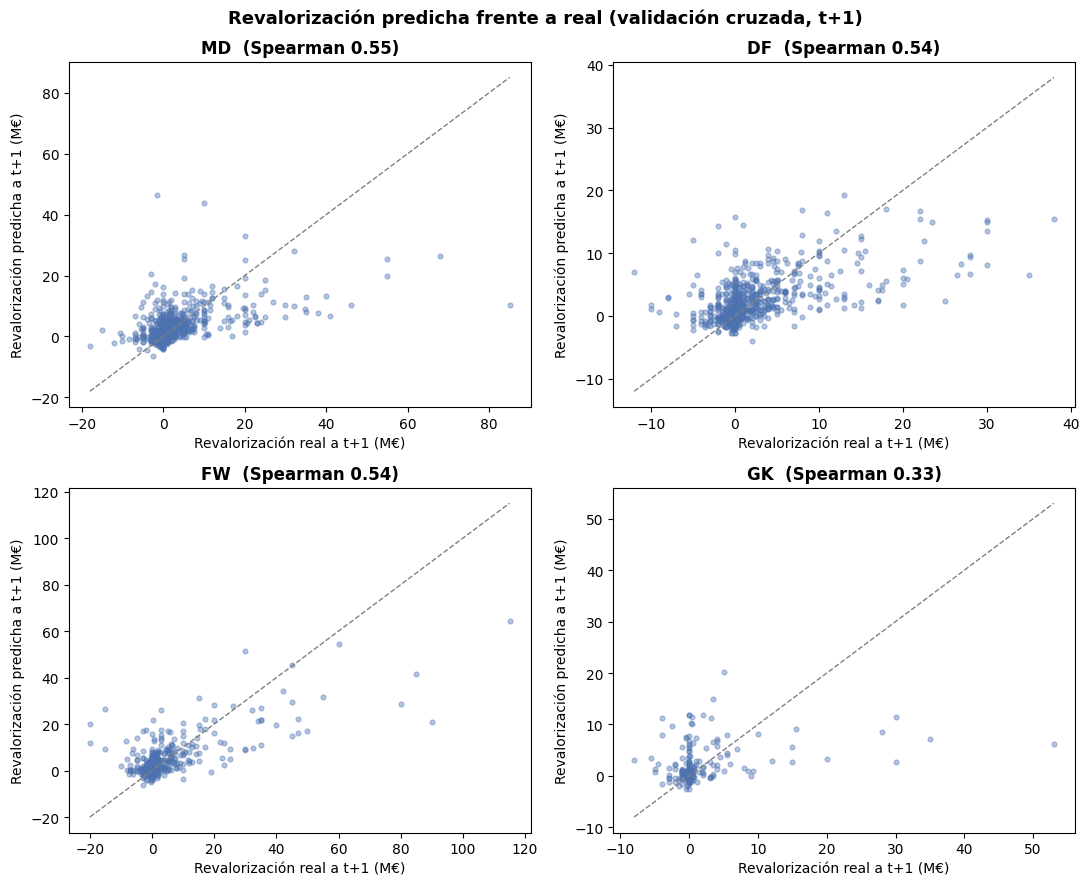

In [10]:
from sklearn.model_selection import cross_val_predict
from matplotlib import pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, b in zip(axes.flat, ["MD", "DF", "FW", "GK"]):
    sub = df[df["position_group"] == b].reset_index(drop=True)
    X = sub[features].apply(pd.to_numeric, errors="coerce")
    y = sub["delta_t1"].to_numpy(dtype=float)
    m = XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8, random_state=42)
    pred = cross_val_predict(m, X, y, cv=KFold(5, shuffle=True, random_state=42))
    ax.scatter(y / 1e6, pred / 1e6, s=12, alpha=0.4, color="#4C72B0")
    lim = [min(y.min(), pred.min()) / 1e6, max(y.max(), pred.max()) / 1e6]
    ax.plot(lim, lim, color="grey", lw=1, ls="--")   # diagonal predicción perfecta
    ax.set_title(f"{b}  (Spearman {spearmanr(y, pred)[0]:.2f})", fontweight="bold")
    ax.set_xlabel("Revalorización real a t+1 (M€)")
    ax.set_ylabel("Revalorización predicha a t+1 (M€)")
fig.suptitle("Revalorización predicha frente a real (validación cruzada, t+1)",
             fontweight="bold", fontsize=13)
fig.tight_layout()
fig.savefig(FIGS / "fig_rent_pred_vs_real.png", dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

### Interpretabilidad: ¿en qué se fija cada modelo?

Más allá de su precisión, un modelo de scouting debe ser interpretable: un club no
ficha a ciegas. Se emplea SHAP (SHapley Additive exPlanations), que descompone cada
predicción en la contribución de cada variable, indicando cuánto y en qué dirección
empuja al valor estimado. Agregando sobre todos los jugadores se obtiene la
importancia de cada feature dentro de su bloque. El análisis se calcula sobre datos
no vistos en el entrenamiento, en coherencia con la validación del resto de la sección.

La comparación entre bloques es el objetivo: revela qué determina la revalorización
en cada posición y justifica, a posteriori, la decisión de modelar por separado. Las
importancias se normalizan dentro de cada bloque (suman el 100%) para que la
comparación no dependa de la distinta escala de revalorización de cada posición.

In [11]:
from sklearn.model_selection import train_test_split
import shap

def shap_importance(df, block, target_col, feats):
    sub = df[df["position_group"] == block].reset_index(drop=True)
    X = sub[feats].apply(pd.to_numeric, errors="coerce")
    y = sub[target_col].to_numpy(dtype=float)
    Xtr, Xte, ytr, _ = train_test_split(X, y, test_size=0.3, random_state=42)

    model = XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8, random_state=42)
    model.fit(Xtr, ytr)
    sv = shap.TreeExplainer(model).shap_values(Xte)          # SHAP sobre datos no vistos
    return pd.Series(np.abs(sv).mean(axis=0), index=feats)   # importancia media por feature

imp = pd.DataFrame({b: shap_importance(df, b, "delta_t1", features)
                    for b in ["MD", "DF", "FW", "GK"]})

for b in ["MD", "DF", "FW", "GK"]:
    print(f"\n── {b}: top 8 features ──")
    print(imp[b].sort_values(ascending=False).head(8).round(0).to_string())


── MD: top 8 features ──
age_at_season               1841245.0
goals_per90                 1037118.0
assists_per90                932230.0
goals_minus_xg               830976.0
total_passes_per90           712950.0
progressive_passes_per90     419819.0
accelerations_per90          341100.0
smart_pass_acc_pct           331588.0

── DF: top 8 features ──
age_at_season                  1989695.0
total_passes_per90              930247.0
smart_pass_acc_pct              452591.0
shots_blocked_per90             316104.0
defending_duels_won_pct         303160.0
dangerous_ball_losses_per90     252024.0
shots_on_target_per90           246081.0
sliding_tackles_won_pct         229572.0

── FW: top 8 features ──
goals_minus_xg                 2473558.0
age_at_season                  1797182.0
goals_per90                    1420646.0
assists_per90                  1071916.0
key_passes_per90                753982.0
air_duels_per90                 695496.0
actions_attacking_third_pct     393330.0
xg_

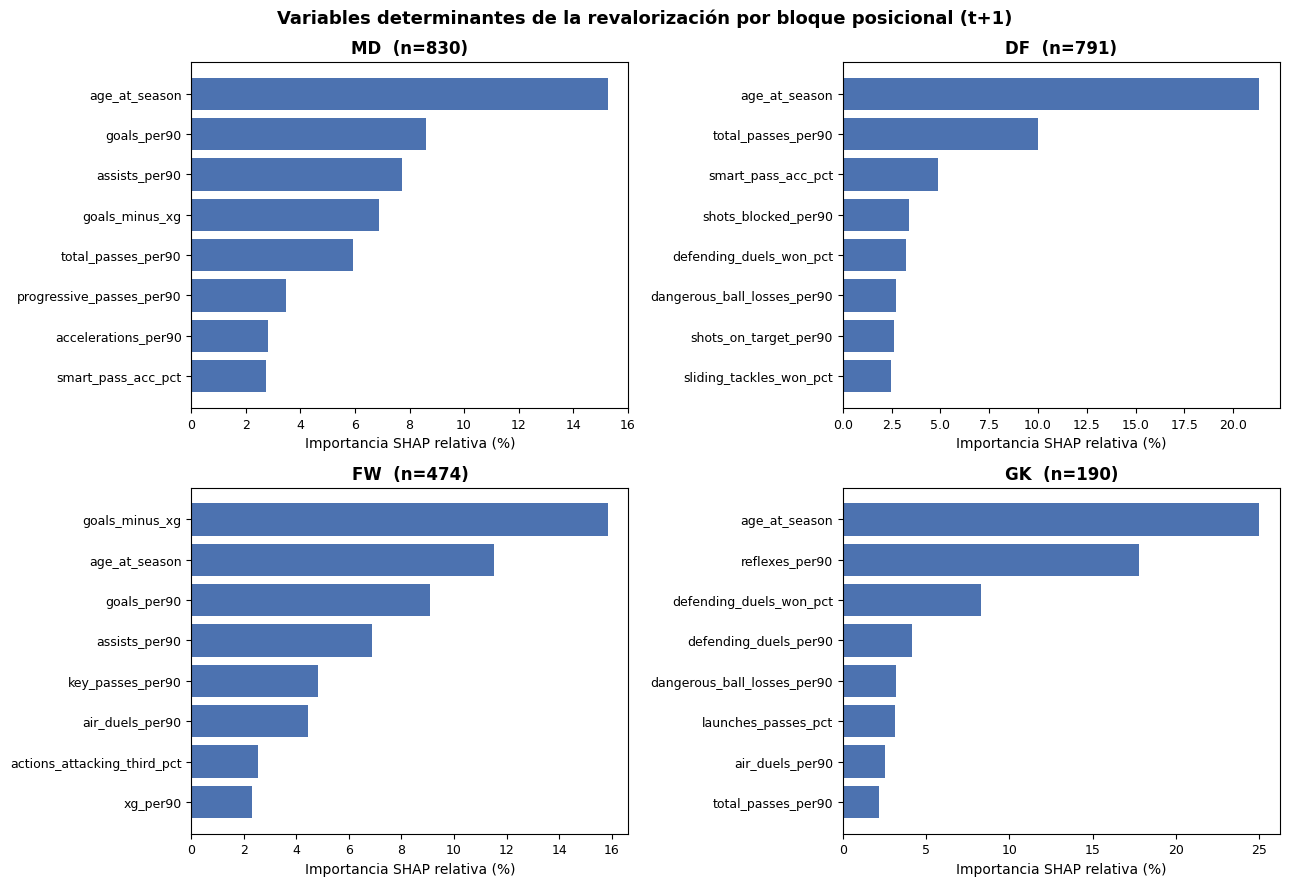

In [12]:
import matplotlib.pyplot as plt

imp_norm = imp.div(imp.sum(axis=0), axis=1) * 100   # % dentro de cada bloque

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, b in zip(axes.flat, ["MD", "DF", "FW", "GK"]):
    top = imp_norm[b].sort_values(ascending=False).head(8)[::-1]
    ax.barh(top.index, top.values, color="#4C72B0")
    ax.set_title(f"{b}  (n={ (df['position_group']==b).sum() })", fontweight="bold")
    ax.set_xlabel("Importancia SHAP relativa (%)")
    ax.tick_params(labelsize=9)
fig.suptitle("Variables determinantes de la revalorización por bloque posicional (t+1)",
             fontweight="bold", fontsize=13)
fig.tight_layout()
fig.savefig(FIGS / "fig_rent_shap_t1.png", dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

La comparación entre bloques confirma la pertinencia de modelar por separado: cada posición se revaloriza por motivos distintos. La edad es el factor transversal, dominante en mediocampistas, defensas y porteros, y segundo en delanteros: a menor edad, mayor recorrido de revalorización, el patrón esperado del mercado. A partir de ahí, cada bloque de campo presenta una firma propia y futbolísticamente coherente. En los delanteros domina goals_minus_xg, la capacidad de marcar por encima de lo esperado: el mercado premia la finalización de élite. En los mediocampistas pesan de forma combinada la creación y la producción ofensiva (asistencias, goles, pase y progresión). En los defensas destaca el juego con balón, con el volumen y la precisión de pase al frente (total_passes_per90, smart_pass_acc_pct) por delante de las acciones defensivas, un reflejo de la valoración creciente del central que inicia el juego en el fútbol contemporáneo.
El bloque de porteros ofrece la confirmación de su limitación, aunque por una vía distinta a la esperada. Sus variables más influyentes tienen sentido para la posición, con la edad y los reflejos (reflexes_per90) al frente, pero ese reparto razonable no se traduce en capacidad predictiva: el modelo no supera al baseline (R² 0.022, Spearman 0.333). El problema no es que el modelo se apoye en ruido, sino que ni siquiera apoyándose en las variables esperables consigue separar al portero que se revaloriza del que no. Este resultado, lejos de invalidar el enfoque, lo refuerza: el método distingue dónde hay señal aprovechable, los jugadores de campo, de dónde la muestra y la naturaleza del valor no la permiten, los porteros, y lo reporta con transparencia.



## 4. Horizonte a dos años y comparación de horizontes

El predictor de la sección anterior anticipa la revalorización a una temporada
vista. Esta sección lo extiende a dos años (Δ€ a t+2 = valor en julio de 2019
menos valor en julio de 2017) para responder a una pregunta de scouting que
plantearon los tutores: si la rentabilidad de un perfil se anticipa mejor a uno
o a dos años. Hay jugadores cuya revalorización es inmediata y otros —jóvenes en
maduración— cuyo salto de valor solo se materializa en la segunda temporada; un
buscador de oportunidades a medio plazo querría distinguirlos. El diseño es
deliberadamente conservador: se reutiliza la misma función de entrenamiento,
las mismas features y la misma validación cruzada, cambiando únicamente la
columna objetivo, de modo que cualquier diferencia entre horizontes sea
atribuible al horizonte y no al método.

El target a dos años conserva los 2.285 jugadores sin pérdida de muestra —la
regla as-of arrastra al 1 de julio de 2019 la última valoración conocida, de
modo que la falta de seguimiento no se traduce en ausencia de filas—, por lo que
el modelo se entrena sobre la muestra completa. La verificación relevante es la
forma de la distribución: si el arrastre dominara, el Δ€ a dos años aparecería
comprimido respecto al de un año, y sucede lo contrario. La desviación típica
crece de 8,5 a 12,2 M€, el percentil 90 pasa de 9 a 15 M€, el mínimo se ahonda
de −20 a −40 M€ y el máximo se eleva de 115 a 165 M€: a dos años el mercado se
mueve más en ambos sentidos, exactamente lo que cabe esperar de un horizonte más
largo y la señal de que el target captura movimiento real. Se declara una
limitación: un 22,4% de la muestra no registra cambio de valoración entre 2018 y
2019 —cota superior del posible estancamiento, que mezcla estabilidad genuina
con valoraciones no actualizadas— y la frescura de las anclas de destino no se
ha verificado por fecha como sí se hizo con el ancla de origen.

In [13]:
# El Δ€ a dos años debe ensanchar el rango, no comprimirlo (señal de target sano)
forma = pd.DataFrame({
    "media_M":   [df["delta_t1"].mean() / 1e6,       df["delta_t2"].mean() / 1e6],
    "mediana_M": [df["delta_t1"].median() / 1e6,     df["delta_t2"].median() / 1e6],
    "p90_M":     [df["delta_t1"].quantile(.9) / 1e6, df["delta_t2"].quantile(.9) / 1e6],
    "min_M":     [df["delta_t1"].min() / 1e6,         df["delta_t2"].min() / 1e6],
    "max_M":     [df["delta_t1"].max() / 1e6,         df["delta_t2"].max() / 1e6],
    "std_M":     [df["delta_t1"].std() / 1e6,         df["delta_t2"].std() / 1e6],
}, index=["delta_t1", "delta_t2"]).round(2)
print(forma)

          media_M  mediana_M  p90_M  min_M  max_M  std_M
delta_t1     2.59        0.0    9.4  -20.0  115.0   8.48
delta_t2     3.65        0.0   15.0  -40.0  165.0  12.15


### 4.1 Modelos a dos años

Se replican los cuatro modelos por bloque con la única diferencia de la columna
objetivo (delta_t2). Mantener idénticos las features, los hiperparámetros y el
esquema de validación cruzada es la condición para que cualquier diferencia
observada entre horizontes sea atribuible al horizonte y no al método.

In [14]:
# Mismos modelos que en la sección 3, cambiando solo el objetivo a delta_t2
res_t2 = pd.DataFrame([evaluate_block(df, b, "delta_t2", features)
                       for b in ["MD", "DF", "FW", "GK"]]).set_index("bloque")
print(res_t2.round(3).to_string())

       horizonte    n  MAE_M  MAE_base_M  RMSE_M     R2  Spearman
bloque                                                           
MD      delta_t2  830  5.336       7.040   9.114  0.351     0.586
DF      delta_t2  791  4.600       5.854   7.954  0.312     0.593
FW      delta_t2  474  7.863       9.351  13.929  0.311     0.486
GK      delta_t2  190  5.772       6.307  10.778  0.082     0.357


Los tres bloques de jugadores de campo baten su baseline también a dos años, y la calidad de ordenación, medida por Spearman, la métrica relevante en un priorizador de oportunidades, se conserva o mejora. El mediocampo sube de 0.550 a 0.586 y la defensa de 0.540 a 0.593, mientras el ataque cede ligeramente de 0.536 a 0.486. Los porteros mejoran de forma marginal sobre el baseline en error absoluto (0.53 M€), pero con un R² de apenas 0.082 y una correlación de orden baja (0.357), de modo que su predictor sigue sin ser fiable por las razones estructurales ya documentadas. El error absoluto crece en los cuatro bloques, aunque no por degradación del modelo sino porque a dos años hay más euros en juego. La métrica que mide aprendizaje es la distancia al baseline, y esa distancia se amplía a dos años en mediocampo (de 0.82 a 1.71 M€) y defensa (de 0.80 a 1.26 M€) y se mantiene alta en ataque (1.49 M€). La lectura conjunta responde a la pregunta de los tutores: en los perfiles de maduración lenta, centrocampistas y centrales que inician juego, la revalorización se anticipa con más nitidez a dos años que a uno, mientras que en los delanteros, cuyo valor responde antes a la finalización, el horizonte corto es ligeramente preferible.

In [15]:
# Comparación de horizontes: ¿dónde se anticipa mejor la revalorización?
comp = pd.DataFrame({
    "Spearman_t1": res_t1["Spearman"],
    "Spearman_t2": res_t2["Spearman"],
    "mejora_t1_M": res_t1["MAE_base_M"] - res_t1["MAE_M"],
    "mejora_t2_M": res_t2["MAE_base_M"] - res_t2["MAE_M"],
}).round(3)
comp["delta_Spearman"] = (comp["Spearman_t2"] - comp["Spearman_t1"]).round(3)
print(comp)

        Spearman_t1  Spearman_t2  mejora_t1_M  mejora_t2_M  delta_Spearman
bloque                                                                    
MD            0.550        0.586        0.818        1.705           0.036
DF            0.540        0.593        0.797        1.255           0.053
FW            0.536        0.486        2.180        1.488          -0.050
GK            0.333        0.357       -0.149        0.534           0.024


La comparación directa entre horizontes responde a la pregunta de los tutores y
revela un patrón futbolístico nítido. La defensa es el bloque donde el horizonte
largo aporta más: su correlación de orden asciende de 0,540 a 0,593 y su ventaja sobre el baseline crece con holgura (de 0,80 a 1,26 M€), de modo que la
revalorización del central que construye juego —un proceso de maduración lento—
se anticipa con bastante más claridad a dos años que a uno. El mediocampo apunta
en la misma dirección de forma más leve. El ataque se comporta al contrario: la
finalización es una señal de valor inmediata, y la calidad de ordenación cede
ligeramente al alargar el horizonte, por lo que en los delanteros el plazo corto
es preferible. Los porteros no alteran su diagnóstico en ningún horizonte. La
lectura de scouting es operativa: a un defensa o centrocampista joven con buenos
indicadores conviene concederle dos temporadas para que el mercado pague su
progresión, mientras que en un finalizador el retorno se materializa antes. Debe
matizarse que solo la diferencia de la defensa es de una magnitud que escapa con
holgura al margen de variación muestral; las del resto de bloques marcan
tendencia pero no deben sobreinterpretarse.

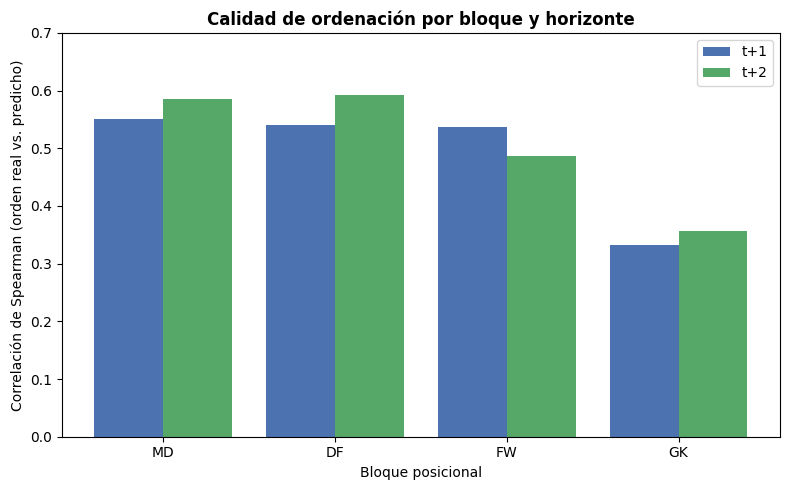

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
bloques = ["MD", "DF", "FW", "GK"]
x = np.arange(len(bloques))
ax.bar(x - 0.2, comp.loc[bloques, "Spearman_t1"], width=0.4, color="#4C72B0", label="t+1")
ax.bar(x + 0.2, comp.loc[bloques, "Spearman_t2"], width=0.4, color="#55A868", label="t+2")
ax.set_xticks(x); ax.set_xticklabels(bloques)
ax.set_xlabel("Bloque posicional")
ax.set_ylabel("Correlación de Spearman (orden real vs. predicho)")
ax.set_title("Calidad de ordenación por bloque y horizonte", fontweight="bold")
ax.set_ylim(0, 0.7); ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "fig_rent_spearman_horizontes.png", dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

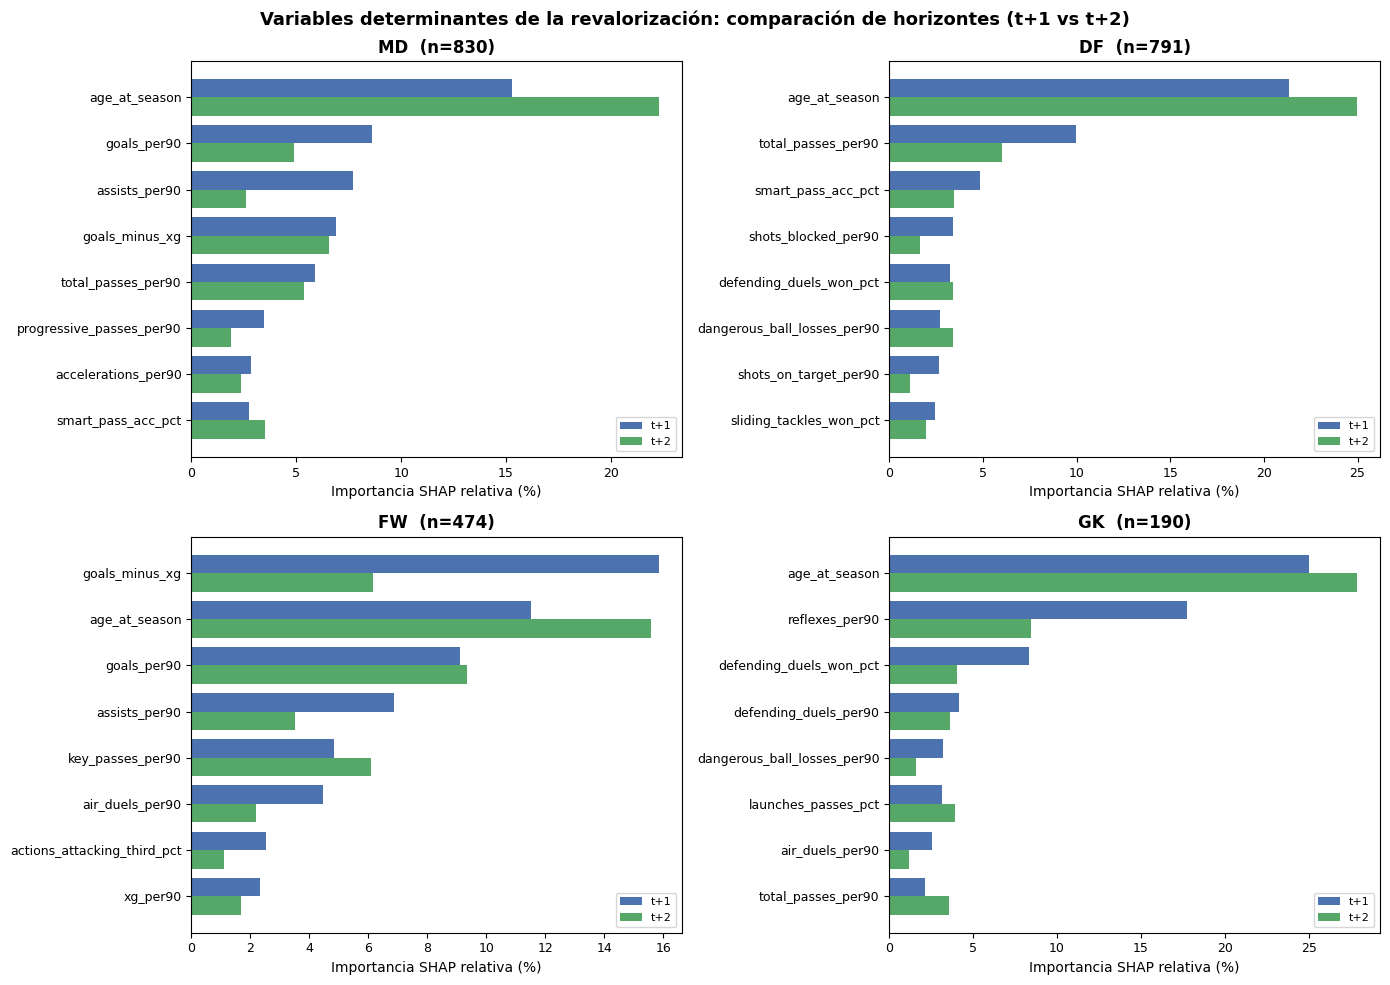

In [17]:
# SHAP comparado por horizonte: barras agrupadas t+1 vs t+2 dentro de cada bloque
imp_t2 = pd.DataFrame({b: shap_importance(df, b, "delta_t2", features)
                       for b in ["MD", "DF", "FW", "GK"]})
imp_t1_norm = imp.div(imp.sum(axis=0), axis=1) * 100
imp_t2_norm = imp_t2.div(imp_t2.sum(axis=0), axis=1) * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, b in zip(axes.flat, ["MD", "DF", "FW", "GK"]):
    orden = imp_t1_norm[b].sort_values(ascending=False).head(8).index   # ranking fijado por t+1
    t1 = imp_t1_norm[b].reindex(orden)[::-1]
    t2 = imp_t2_norm[b].reindex(orden)[::-1]
    ypos = np.arange(len(orden))
    ax.barh(ypos + 0.2, t1.values, height=0.4, color="#4C72B0", label="t+1")
    ax.barh(ypos - 0.2, t2.values, height=0.4, color="#55A868", label="t+2")
    ax.set_yticks(ypos)
    ax.set_yticklabels(t1.index)
    ax.set_title(f"{b}  (n={ (df['position_group']==b).sum() })", fontweight="bold")
    ax.set_xlabel("Importancia SHAP relativa (%)")
    ax.tick_params(labelsize=9)
    ax.legend(fontsize=8, loc="lower right")
fig.suptitle("Variables determinantes de la revalorización: comparación de horizontes (t+1 vs t+2)",
             fontweight="bold", fontsize=13)
fig.tight_layout()
fig.savefig(FIGS / "fig_rent_shap_horizontes.png", dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

La comparación de la importancia SHAP entre horizontes muestra que la firma de
cada bloque es estable: las variables que encabezan la explicación a un año son
las mismas que a dos, sin reordenamientos bruscos ni aparición de factores
nuevos. Lo que cambia es el peso relativo, y lo hace siguiendo un patrón
transversal con sentido futbolístico: la edad gana protagonismo al alargar el
horizonte en todos los bloques de campo. El caso más expresivo es el de los
delanteros, donde `age_at_season` pasa de ser el segundo factor a un año a
desplazar a `goals_minus_xg` como primero a dos años; en mediocampistas y defensas
la edad, ya dominante a un año, refuerza aún más su peso. La interpretación es
coherente con la lógica de la proyección a medio plazo: a corto, el valor
responde sobre todo al rendimiento observado en la temporada —singularmente la
finalización en los delanteros—, mientras que a dos años la juventud, como
indicador del recorrido futuro, pesa más que el dato puntual de una campaña. Los porteros mantienen en ambos horizontes el mismo diagnóstico. Su importancia la encabezan variables con sentido para la posición, la edad y los reflejos, pero ese reparto razonable no se traduce en una ordenación útil del bloque en ningún horizonte, lo que confirma desde la interpretabilidad la limitación estructural de su predictor.

## 5. Integración en el motor de scouting

Las dos piezas del sistema convergen aquí. El motor de similitud por estilo del
notebook anterior identifica jugadores con un perfil de juego análogo a un
referente; el modelo de rentabilidad de este notebook estima cuánto se
revalorizará cada uno. Combinándolos, la salida deja de ser una simple lista de
parecidos y se convierte en una herramienta de decisión: dado un jugador de
referencia, se recuperan los más similares en estilo y se ordenan por
revalorización esperada. Es la lógica de los clubes que han hecho del scouting
una ventaja —encontrar el perfil deseado al menor coste y mayor recorrido—:
entre varios jugadores de estilo equivalente, el de mayor rentabilidad prevista
no tiene por qué ser el más parecido.

La revalorización esperada de cada jugador procede de las predicciones fuera de
muestra de la validación cruzada, no de un modelo reentrenado sobre el conjunto
completo. Cada estimación la produjo un modelo que no vio a ese jugador durante
el entrenamiento, de modo que las cifras mostradas son honestas y consistentes
con las métricas reportadas en las secciones anteriores. Dado que los candidatos
a recomendar ya pertenecen a la muestra, no es necesario predecir sobre
jugadores nuevos; una herramienta en producción reentrenaría con todos los datos
para evaluar fichajes externos, matiz que se declara como tal.

In [18]:
# Predicción Δ€ fuera de muestra por jugador (misma CV que las secciones 3-4: mismas cifras)
def oof_predict(df, target_col, features, blocks=("MD", "DF", "FW", "GK"), n_splits=5, seed=42):
    pred = pd.Series(np.nan, index=df.index, dtype=float)
    for b in blocks:
        sub = df[df["position_group"] == b]
        X = sub[features].apply(pd.to_numeric, errors="coerce")
        y = sub[target_col].to_numpy(dtype=float)
        for tr, te in KFold(n_splits, shuffle=True, random_state=seed).split(X):
            m = XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8,
                             objective="reg:squarederror", random_state=seed)
            m.fit(X.iloc[tr], y[tr])
            pred.loc[X.index[te]] = m.predict(X.iloc[te])
    return pred

scout = df[["player_id", "tm_id", "short_name", "position_group", "t0", "delta_t1", "delta_t2"]].copy()
scout["pred_delta_t1"] = oof_predict(df, "delta_t1", features)
scout["pred_delta_t2"] = oof_predict(df, "delta_t2", features)

print(scout.shape)
print(scout.head().round(0).to_string(index=False))

(2285, 9)
 player_id  tm_id      short_name position_group         t0   delta_t1   delta_t2  pred_delta_t1  pred_delta_t2
        33 146227    J. Cillessen             GK  9000000.0        0.0  9000000.0      -655968.0       339432.0
        36  42710 T. Alderweireld             DF 35000000.0  5000000.0  5000000.0      1493890.0     -5304212.0
        38  12282        D. Blind             DF 22000000.0 -4000000.0  2000000.0      -198811.0      2436511.0
        45  45548 G. van der Wiel             DF  3000000.0 -2000000.0 -2300000.0     -2360536.0     -1960885.0
        48  43250   J. Vertonghen             DF 28000000.0  4000000.0        0.0      1593366.0     -2585717.0


### 5.1 Robustez del orden: intervalos de confianza del Spearman

La calidad del predictor se resume en la correlación de Spearman entre la
revalorización real y la estimada, y hasta aquí se ha reportado como un valor
único por bloque y horizonte. Un valor único no dice cuánta incertidumbre
arrastra ni si la mejora de un horizonte sobre otro supera el ruido muestral.

Se cuantifica esa incertidumbre con un bootstrap sobre las predicciones fuera
de muestra. Para cada bloque se remuestrean con reemplazo los jugadores dos mil
veces, se recalcula el Spearman en cada réplica y se toman los percentiles 2,5
y 97,5 como intervalo de confianza al 95 %. El remuestreo es pareado: la misma
selección de jugadores se aplica a los dos horizontes, de modo que la diferencia
entre t+1 y t+2 conserva la correlación que induce compartir muestra y recibe su
propio intervalo. El procedimiento mide la variabilidad del estadístico de orden
sobre la muestra de jugadores con los modelos ya ajustados, no la del reajuste
del modelo en cada réplica. La lectura operativa es directa: si el intervalo de
la diferencia excluye el cero, el horizonte distingue de verdad; si lo contiene,
la diferencia es indistinguible del ruido y no debe sobreinterpretarse.

In [38]:
from scipy.stats import spearmanr

B   = 2000
rng = np.random.default_rng(42)
bloques = ["MD", "DF", "FW", "GK"]

filas = []
for b in bloques:
    g = scout[scout["position_group"] == b]
    yt1, pt1 = g["delta_t1"].to_numpy(float), g["pred_delta_t1"].to_numpy(float)
    yt2, pt2 = g["delta_t2"].to_numpy(float), g["pred_delta_t2"].to_numpy(float)
    n = len(g)

    s1 = spearmanr(yt1, pt1).correlation   # punto: coincide con las tablas de §3 y §4
    s2 = spearmanr(yt2, pt2).correlation
    d  = s2 - s1

    bs1, bs2, bd = np.empty(B), np.empty(B), np.empty(B)
    for j in range(B):
        idx = rng.integers(0, n, n)        # mismos jugadores en ambos horizontes
        bs1[j] = spearmanr(yt1[idx], pt1[idx]).correlation
        bs2[j] = spearmanr(yt2[idx], pt2[idx]).correlation
        bd[j]  = bs2[j] - bs1[j]

    pc = lambda a: np.percentile(a, [2.5, 97.5])
    l1, u1 = pc(bs1); l2, u2 = pc(bs2); ld, ud = pc(bd)
    filas.append({
        "bloque": b, "n": n,
        "Sp_t1": round(s1, 3), "IC_t1": f"[{l1:.3f}, {u1:.3f}]",
        "Sp_t2": round(s2, 3), "IC_t2": f"[{l2:.3f}, {u2:.3f}]",
        "d(t2-t1)": round(d, 3), "IC_d": f"[{ld:.3f}, {ud:.3f}]",
        "d!=0 95%": "si" if (ld > 0 or ud < 0) else "no",
    })

ci_spearman = pd.DataFrame(filas).set_index("bloque")
print(ci_spearman.to_string())

          n  Sp_t1           IC_t1  Sp_t2           IC_t2  d(t2-t1)             IC_d d!=0 95%
bloque                                                                                       
MD      830  0.550  [0.493, 0.604]  0.586  [0.530, 0.634]     0.036  [-0.016, 0.089]       no
DF      791  0.540  [0.481, 0.594]  0.593  [0.539, 0.641]     0.053  [-0.009, 0.109]       no
FW      474  0.536  [0.454, 0.614]  0.486  [0.398, 0.564]    -0.050  [-0.129, 0.026]       no
GK      190  0.333  [0.192, 0.464]  0.357  [0.220, 0.484]     0.024  [-0.105, 0.147]       no


### 5.2 Carga del motor de similitud e intersección de universos

El motor de similitud se carga desde el artefacto persistido en el notebook
anterior, sin reejecutar el pipeline de clustering. Conviene advertir que las dos
piezas operan sobre universos distintos: el motor se entrenó sobre los 1.634
jugadores con al menos 900 minutos, mientras que el predictor de rentabilidad
cubre los 2.285 que disponen de target de revalorización, sin umbral de minutos.
La integración cruza ambos por `player_id`, de modo que un candidato propuesto por
el motor solo mostrará revalorización esperada si pertenece también al universo
del predictor. Se cuantifica primero esa intersección, que delimita el alcance
real del sistema integrado.

In [19]:
import sys
import joblib
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[0]))   # raíz del repo en el path (mismo patrón que el .env)

from src.models.similarity import jugadores_similares, bloque_de

ARTIFACTS = Path.cwd().parents[0] / "models" / "clustering"
engine_art = joblib.load(ARTIFACTS / "similarity_engine.joblib")
sim_index = engine_art["sim_index"]
NAMES_SIM = engine_art["names"]

# player_id de cada universo
ids_motor = pd.concat([sim_index[b]["meta"][["player_id", "short_name"]] for b in ["GK", "DF", "MD", "FW"]],
                      ignore_index=True)
ids_pred = scout[["player_id"]].drop_duplicates()

inter = ids_motor.merge(ids_pred, on="player_id", how="inner")
print(f"Universo motor (≥900 min):        {len(ids_motor)}")
print(f"Universo predictor (target Δ€):   {len(ids_pred)}")
print(f"Intersección (similares con Δ€):  {len(inter)}")
print(f"En motor sin Δ€:                  {len(ids_motor) - len(inter)}")

Universo motor (≥900 min):        1634
Universo predictor (target Δ€):   2285
Intersección (similares con Δ€):  1522
En motor sin Δ€:                  112


### 5.3 Función de scouting integrada

A la consulta de similitud del módulo se le añaden las dos dimensiones que aporta
este notebook: la revalorización esperada de cada candidato en ambos horizontes,
procedente de las predicciones fuera de muestra del predictor por bloque, y el
multiplicador relativo que esa revalorización supone sobre el valor de partida.
A la pregunta de estilo —quién juega como el referente— se suma así la de retorno
—cuál de ellos se revaloriza más—, que es la que convierte una lista de parecidos
en una decisión de scouting.

El multiplicador (uno más la revalorización esperada sobre el valor inicial)
captura la lógica de comprar barato para revender: cinco millones de plusvalía
pesan de forma muy distinta sobre un jugador de dos millones que sobre uno de
cincuenta. Solo se calcula cuando el valor de partida supera el millón de euros,
pues por debajo de ese suelo una revalorización modesta produce multiplicadores
desorbitados que son artefacto del denominador y no señal de oportunidad. Los
candidatos sin valor fiable conservan su revalorización absoluta pero no su
multiplicador.

In [20]:
# Valor de mercado contemporáneo (17/18), igual que en el motor de nb05
market_values = pd.read_sql(
    "SELECT player_id, market_value_eur FROM gold.player_market_values", engine)
print(f"Valores de mercado: {len(market_values)} jugadores")

Valores de mercado: 2369 jugadores


In [21]:
SUELO_T0 = 1_000_000   # valor inicial mínimo para que el multiplicador sea informativo

pred_por_id = scout.set_index("player_id")[["pred_delta_t1", "pred_delta_t2", "t0"]]

def scouting(nombre, top_n=10, horizonte="t1", afinidad_min=70,
             edad_max=None, valor_max=None, ligas=None,
             liga_distinta=False, sobrerend_min=None):
    base = jugadores_similares(sim_index, nombre, descriptores=df,
                               market_values=market_values, top_n=300)
    if base is None:
        print(f"'{nombre}' no encontrado.")
        return None

    base = base.merge(pred_por_id, on="player_id", how="left")

    # Ambos horizontes: Δ€ en M€ y multiplicador (×valor) con suelo a t0
    suelo = base["t0"] >= SUELO_T0
    for h in ("t1", "t2"):
        base[f"Δ€_{h}_M"] = (base[f"pred_delta_{h}"] / 1e6).round(1)
        base[f"×_{h}"] = np.where(suelo, (1 + base[f"pred_delta_{h}"] / base["t0"]).round(2), np.nan)

    base = base[base["afinidad"] >= afinidad_min]                  # similitud filtra primero
    if edad_max is not None:      base = base[base["age_at_season"] <= edad_max]
    if valor_max is not None:     base = base[base["valor_M"] <= valor_max]
    if ligas is not None:         base = base[base["liga"].isin(ligas)]
    if sobrerend_min is not None: base = base[base["goals_minus_xg"] >= sobrerend_min]
    if liga_distinta:
        liga_obj = sim_index[bloque_de(sim_index, nombre)]["meta"] \
                   .set_index("short_name").loc[nombre, "liga"]
        base = base[base["liga"] != liga_obj]

    base = base.sort_values(f"pred_delta_{horizonte}", ascending=False, na_position="last")  # rentabilidad ordena
    cols = ["short_name", "afinidad", "archetype", "liga", "age_at_season", "valor_M",
            "Δ€_t1_M", "×_t1", "Δ€_t2_M", "×_t2", "goals_minus_xg"]
    return base[cols].head(top_n).rename(
        columns={"short_name": "jugador", "age_at_season": "edad",
                 "valor_M": "valor_M€", "goals_minus_xg": "G−xG"}
    ).reset_index(drop=True)

In [22]:
scouting("Isco", top_n=8, edad_max=26, valor_max=20.0, horizonte="t1")

,jugador,afinidad,archetype,liga,edad,valor_M€,Δ€_t1_M,×_t1,Δ€_t2_M,×_t2,G−xG
0,S. Gnabry,70.9,Mediocentro ofensivo,Bundesliga,22.1,20.0,25.6,2.70,23.4,2.56,4.9592
1,A. Iwobi,81.7,Mediocentro ofensivo,Premier League,21.3,10.0,19.2,2.92,22.1,3.21,-0.4698
2,A. Januzaj,70.5,Mediocentro ofensivo,La Liga,22.6,10.0,13.9,2.98,22.8,4.26,-2.4848
3,Pablo Fornals,80.1,Mediocentro ofensivo,La Liga,21.5,15.0,12.7,2.27,11.6,2.16,0.1774
4,F. Tait,80.0,Mediocentro ofensivo,Ligue 1,24.6,5.0,5.0,NaN,12.8,NaN,0.0521
5,Thiago Mendes,73.4,Mediocentro ofensivo,Ligue 1,25.5,5.5,4.4,2.09,6.3,2.57,-0.1541
6,R. Saponara,70.1,Mediocentro ofensivo,Serie A,25.7,9.0,-1.6,0.86,-2.7,0.75,-1.6312


### 5.4 Galería de casos: flexibilidad del sistema

Los dos escenarios canónicos se ejecutan aquí sobre perfiles y contextos
deportivos diversos, para mostrar que el sistema no está especializado en un tipo
de jugador sino que opera de forma homogénea en todos los bloques posicionales y
ante necesidades de club distintas. Cada consulta activa una combinación de
palancas diferente —presupuesto, edad, liga, horizonte de revalorización— que
traduce una estrategia deportiva concreta. La afinidad de estilo gobierna en
todos los casos la composición de la lista; la revalorización esperada, su orden.

**Caso A — Sustitución de un central de élite.** El primer escenario responde a
la necesidad más frecuente de una dirección deportiva: cubrir la salida de un
titular con un perfil equivalente que el club pueda permitirse. Se parte de un
central de salida de primer nivel y se busca su mismo estilo de juego dentro de
un techo de presupuesto exigente, sin restricción de edad ni de liga. La consulta
ilustra el bloque defensivo —el de mayor coherencia interna del clustering— y la
palanca de presupuesto como filtro central de la operación.

In [23]:
# Sustitución: relevo de un central de élite por debajo de 25 M€
scouting("K. Koulibaly", top_n=8, valor_max=25.0, horizonte="t1")

,jugador,afinidad,archetype,liga,edad,valor_M€,Δ€_t1_M,×_t1,Δ€_t2_M,×_t2,G−xG
0,M. Sarr,83.3,Central constructor,Ligue 1,18.6,15.0,16.4,5.10,32.9,9.23,-0.4782
1,D. Rugani,73.4,Central constructor,Serie A,23.1,17.0,10.4,1.61,9.5,1.56,0.6069
2,A. Mandi,72.7,Central constructor,La Liga,25.9,6.0,8.5,2.41,6.2,2.03,-0.5803
3,D. Lovren,73.6,Central constructor,Premier League,28.2,17.0,7.9,1.47,-0.8,0.95,-0.1366
4,V. Kompany,84.3,Central constructor,Premier League,31.4,10.0,7.0,1.32,-1.5,0.93,-0.2555
5,Albiol,85.9,Central constructor,Serie A,32.0,8.0,4.9,1.62,-3.7,0.53,0.7836
6,M. Musacchio,70.3,Central constructor,Serie A,27.0,12.5,3.5,1.20,2.9,1.16,-0.5878
7,Thiago Silva,77.6,Central constructor,Ligue 1,32.9,10.0,3.1,1.26,-2.0,0.83,0.2472


**Caso B — Oportunidad de mercado en la medular.** El segundo escenario aplica
la estrategia de identificación temprana de talento sobre el centro del campo,
el bloque de mayor densidad del sistema. Partiendo de un mediocentro ofensivo
consolidado, se busca su perfil en una versión joven y en una liga distinta a la
suya, donde el mismo estilo aún no cotiza a precio de mercado maduro. La consulta
se ordena por revalorización a dos años, coherente con el hallazgo de la sección
anterior —la rentabilidad de los perfiles en maduración se anticipa mejor a medio
plazo—, de modo que no persigue un relevo inmediato sino una apuesta de futuro.
Es la traducción literal de la lógica que clubes como Brentford o Brighton han
convertido en ventaja competitiva.

In [24]:
# Caso B — oportunidad: perfil tipo Mkhitaryan, joven, otra liga, ordenado por revalorización a 2 años
scouting("H. Mkhitaryan", top_n=8, edad_max=24, valor_max=60.0, liga_distinta=True, horizonte="t2")

,jugador,afinidad,archetype,liga,edad,valor_M€,Δ€_t1_M,×_t1,Δ€_t2_M,×_t2,G−xG
0,C. Pulisic,75.0,Mediocentro ofensivo,Bundesliga,19.0,45.0,11.1,1.62,41.1,3.28,-2.0258
1,Mikel Oyarzabal,76.0,Mediocentro ofensivo,La Liga,20.4,35.0,13.6,1.91,34.7,3.32,5.0721
2,J. Brandt,78.4,Mediocentro ofensivo,Bundesliga,21.3,40.0,25.0,2.25,27.5,2.38,4.1565
3,S. Gnabry,76.7,Mediocentro ofensivo,Bundesliga,22.1,20.0,25.6,2.70,23.4,2.56,4.9592
4,A. Januzaj,79.6,Mediocentro ofensivo,La Liga,22.6,10.0,13.9,2.98,22.8,4.26,-2.4848
5,M. Sanson,75.2,Mediocentro ofensivo,Ligue 1,23.0,18.0,13.9,2.16,19.8,2.65,2.7521
6,Marco Asensio,79.1,Mediocentro ofensivo,La Liga,21.6,50.0,19.7,1.99,19.6,1.98,0.4422
7,I. Sarr,74.1,Mediocentro ofensivo,Ligue 1,19.5,14.0,10.3,5.12,19.3,8.74,1.3787


**Caso C — Entorno estilístico de un creador.** El tercer escenario prescinde del
techo de presupuesto para responder a una pregunta distinta: dado un delantero
creativo consolidado, qué perfiles comparten su estilo y cuál ofrece mayor
recorrido de revalorización. La consulta ilustra además una propiedad del bloque
ofensivo identificada en el clustering: es el de fronteras más difusas y, por
tanto, el de vecindarios más reducidos —el estilo de un delantero es el más
individual—, de modo que la lista de afines es naturalmente más corta que en
defensa o medular. Conviene aquí una cautela de lectura que el propio sistema
expone: un multiplicador muy elevado sobre un valor de partida modesto, sin un
sobrerrendimiento que lo respalde, es señal de incertidumbre del modelo y no de
oportunidad, y la columna de goles sobre lo esperado permite detectarlo de un
vistazo.

In [25]:
# Caso C — estrella creativa: entorno afín a Coutinho, ordenado por recorrido a 1 año
scouting("Philippe Coutinho", top_n=8, edad_max=27, horizonte="t1")

,jugador,afinidad,archetype,liga,edad,valor_M€,Δ€_t1_M,×_t1,Δ€_t2_M,×_t2,G−xG
0,Neymar,85.4,Delantero creativo,Ligue 1,25.6,180.0,28.8,1.29,38.5,1.39,3.2803
1,M. Depay,89.0,Delantero creativo,Ligue 1,23.5,45.0,27.6,2.45,52.1,3.74,4.8149
2,E. Hazard,81.7,Delantero creativo,Premier League,26.7,110.0,26.8,1.36,14.1,1.19,3.6868
3,L. Insigne,81.5,Delantero creativo,Serie A,26.2,60.0,9.4,1.27,20.3,1.58,-6.2328
4,A. Ljajić,70.8,Delantero creativo,Serie A,25.9,13.0,7.9,1.72,8.4,1.76,1.1768
5,J. Bamba,70.3,Delantero creativo,Ligue 1,21.4,8.0,7.4,8.40,6.7,7.67,-2.1018
6,A. Schürrle,76.8,Delantero creativo,Bundesliga,26.8,15.0,4.6,1.23,7.2,1.36,-1.9879
7,A. Kramarić,71.9,Delantero creativo,Bundesliga,26.2,27.0,3.4,1.23,12.7,1.85,0.8000


Los tres escenarios, sobre tres bloques posicionales distintos, muestran un
sistema que opera de forma homogénea y cuya recomendación responde a las palancas
que el usuario activa. El caso del central ilustra el valor de la doble
estimación temporal: el perfil más rentable a dos años —un central de dieciocho
años cuya revalorización prevista se multiplica por nueve— no es el más destacado
a uno, mientras que los veteranos del mismo estilo, rentables a corto, entran en
depreciación a medio plazo. Es la traducción operativa del hallazgo de la sección
anterior: en defensa, el horizonte largo discrimina mejor la proyección.

El caso de la medular lo confirma desde el orden de la lista. Al ordenar por
revalorización a dos años, los candidatos que encabezaban el ranking a un año
ceden su puesto a perfiles —Pulisic, Oyarzabal— discretos en lo inmediato pero
de mayor recorrido a medio plazo, precisamente los jugadores en maduración que un
club que planifica a dos temporadas querría priorizar. El horizonte de
revalorización no es, por tanto, un dato accesorio sino una palanca que reordena
la recomendación según el plazo de la estrategia deportiva.

El caso del creador expone tanto el alcance como los límites del sistema. Sin
techo de presupuesto, la consulta mapea el entorno estilístico completo de un
delantero de élite, y en su cabeza aparecen los perfiles más afines con
independencia de su coste —los mejores del mundo en ese estilo—; el valor de
scouting reside en los candidatos intermedios, estilísticamente muy próximos pero
asequibles y con recorrido. La lista incluye además, de forma deliberadamente no
filtrada, un candidato con un multiplicador desorbitado sobre un valor de partida
modesto y un rendimiento por debajo de su xG: el sistema no lo oculta, lo expone
junto a la columna de sobrerrendimiento que permite reconocerlo como
incertidumbre del modelo y no como oportunidad. La herramienta prioriza
candidatos a investigar y deja, en todos los casos, el veredicto al analista.

### 5.5 Ficha comparativa de scouting

Las tablas ordenan y filtran candidatos, pero un cuerpo técnico lee perfiles de
un vistazo. El formato consolidado para ello es el gráfico de percentiles por
posición, que sitúa cada métrica del jugador como su percentil dentro del bloque
—«supera al ochenta por ciento de los centrales en pases progresivos»— y
superpone el perfil del objetivo y el de su recomendación. Dos perfiles que se
solapan casi por completo son la traducción visual de una afinidad alta: la
similitud del coseno, hasta aquí un número, se vuelve forma reconocible. Se
cierran con esta figura los dos casos de la galería de mayor afinidad —el central
de élite frente a su relevo joven y el creador frente a su perfil más próximo—,
recordando que el percentil describe cuánto presenta un jugador de cada rasgo
respecto a sus pares, no cuán bueno es: la figura describe estilo, mientras que
la revalorización y el rendimiento ya tabulados aportan el juicio de calidad.

In [31]:
from mplsoccer import PyPizza
from scipy.stats import percentileofscore
from sklearn.metrics.pairwise import cosine_similarity

PIZZA = {
    'GK': {'Distribución': ['pass_acc_pct', 'simple_passes_pct', 'launches_passes_pct',
                            'avg_pass_distance_m', 'high_passes_pct', 'total_passes_per90',
                            'hand_passes_per90', 'goal_kicks_per90'],
           'Parada': ['saves_per90', 'reflexes_per90'],
           'Salida': ['gk_leaving_line_per90', 'avg_action_x_m']},
    'DF': {'Construcción': ['pass_acc_pct', 'progressive_passes_per90', 'avg_pass_distance_m',
                            'crosses_passes_pct', 'key_passes_per90'],
           'Defensa': ['defending_duels_won_pct', 'interceptions_per90', 'clearances_per90',
                       'sliding_tackles_per90', 'air_duels_won_pct'],
           'Posición': ['avg_action_x_m']},
    'MD': {'Creación': ['total_passes_per90', 'pass_acc_pct', 'progressive_passes_per90',
                        'key_passes_per90', 'smart_passes_pct'],
           'Finalización': ['xg_per90', 'shots_on_target_per90'],
           'Defensa': ['defending_duels_won_pct', 'interceptions_per90', 'air_duels_won_pct'],
           'Conducción': ['accelerations_per90']},
    'FW': {'Finalización': ['xg_per90', 'shots_per90', 'shots_on_target_per90', 'xg_per_shot'],
           'Creación': ['key_passes_per90', 'assists_per90'],
           'Progresión': ['progressive_passes_per90', 'accelerations_per90'],
           'Juego aéreo': ['air_duels_won_pct', 'head_passes_pct'],
           'Posición': ['avg_action_x_m']},
}

LABELS = {
    'pass_acc_pct': '% acierto\npase', 'simple_passes_pct': '% pase\nsencillo',
    'launches_passes_pct': '% pase\nen largo', 'avg_pass_distance_m': 'Dist. media\npase (m)',
    'high_passes_pct': '% pase\naéreo', 'total_passes_per90': 'Pases/90',
    'hand_passes_per90': 'Saques\nde mano/90', 'goal_kicks_per90': 'Saques de\npuerta/90',
    'saves_per90': 'Paradas/90', 'reflexes_per90': 'Reflejos/90',
    'gk_leaving_line_per90': 'Salidas/90', 'avg_action_x_m': 'Pos. media\nen campo (m)',
    'progressive_passes_per90': 'Pases\nprogr./90', 'crosses_passes_pct': '% centros',
    'key_passes_per90': 'Pases\nclave/90', 'defending_duels_won_pct': '% duelos\ndef. ganados',
    'interceptions_per90': 'Intercep./90', 'clearances_per90': 'Despejes/90',
    'sliding_tackles_per90': 'Entradas/90', 'air_duels_won_pct': '% duelos\naéreos gan.',
    'smart_passes_pct': '% pases\nentre líneas', 'xg_per90': 'xG/90',
    'shots_on_target_per90': 'Tiros a\npuerta/90', 'accelerations_per90': 'Conducc.\nrápidas/90',
    'shots_per90': 'Tiros/90', 'xg_per_shot': 'xG\npor tiro', 'assists_per90': 'Asist./90',
    'head_passes_pct': '% pase\nde cabeza',
}

FASE_COLOR = {'Construcción': '#2a9d8f', 'Creación': '#2a9d8f', 'Distribución': '#2a9d8f',
              'Finalización': '#e76f51', 'Defensa': '#264653', 'Parada': '#264653',
              'Posición': '#8d99ae', 'Salida': '#8d99ae', 'Conducción': '#e9c46a',
              'Progresión': '#e9c46a', 'Juego aéreo': '#f4a261'}

def _pid(b, nombre):
    m = sim_index[b]["meta"]
    return m.loc[m["short_name"] == nombre, "player_id"].iloc[0]

def percentiles_bloque(b, player_id):
    feats = [f for grp in PIZZA[b].values() for f in grp]
    pool = df[(df["position_group"] == b) & (df["meets_450min"])]
    fila = df[df["player_id"] == player_id].iloc[0]
    pct = [round(percentileofscore(pool[f].dropna(), fila[f], kind="mean")) for f in feats]
    return feats, pct

def _datos_cabecera(b, nombre):
    pid = sim_index[b]["meta"].query("short_name == @nombre")["player_id"].iloc[0]
    edad = df.loc[df["player_id"] == pid, "age_at_season"].iloc[0]
    mv = market_values.loc[market_values["player_id"] == pid, "market_value_eur"]
    val = f"{mv.iloc[0]/1e6:.0f} M€" if len(mv) else "s/d"
    s = scout[scout["player_id"] == pid]
    if len(s):
        d1, d2, t0 = s["pred_delta_t1"].iloc[0], s["pred_delta_t2"].iloc[0], s["t0"].iloc[0]
        m2 = f" (×{1 + d2/t0:.1f})" if t0 >= SUELO_T0 else ""
        delta = f"Δ€  t+1 {d1/1e6:+.1f}M  ·  t+2 {d2/1e6:+.1f}M{m2}"
    else:
        delta = "Δ€  no disponible (fuera del universo de entrenamiento)"
    return f"{edad:.0f} años · {val}", delta

def ficha_comparativa(objetivo, similar, b=None):
    b = b or bloque_de(sim_index, objetivo)
    feats = [f for grp in PIZZA[b].values() for f in grp]
    slice_colors = [FASE_COLOR[fase] for fase, grp in PIZZA[b].items() for _ in grp]
    params = [LABELS[f] for f in feats]

    _, pct_o = percentiles_bloque(b, _pid(b, objetivo))
    _, pct_s = percentiles_bloque(b, _pid(b, similar))

    io, isim = sim_index[b]["pos"][objetivo], sim_index[b]["pos"][similar]
    afin = round(cosine_similarity(sim_index[b]["X"][io:io+1],
                                   sim_index[b]["X"][isim:isim+1])[0][0] * 100, 1)

    perfil_o, delta_o = _datos_cabecera(b, objetivo)
    perfil_s, delta_s = _datos_cabecera(b, similar)

    baker = PyPizza(params=params, background_color="#f7f7f5",
                    straight_line_color="#cfcfcf", straight_line_lw=1,
                    last_circle_lw=1, last_circle_color="#cfcfcf",
                    other_circle_lw=0, inner_circle_size=11)
    fig, ax = baker.make_pizza(
        pct_o, compare_values=pct_s, figsize=(9, 11),
        slice_colors=slice_colors, value_colors=["#222"]*len(params),
        value_bck_colors=slice_colors,
        kwargs_slices=dict(edgecolor="#f7f7f5", zorder=2, linewidth=1),
        kwargs_compare=dict(facecolor="none", edgecolor="#222", linewidth=2.2, zorder=3),
        kwargs_params=dict(color="#222", fontsize=9),
        kwargs_values=dict(color="#fff", fontsize=9, zorder=3,
                           bbox=dict(edgecolor="none", boxstyle="round,pad=0.2")),
        kwargs_compare_values=dict(color="#222", fontsize=9, alpha=0))

    # Cabecera: título + datos de decisión de cada jugador
    fig.text(0.05, 0.975, f"{objetivo}  vs  {similar}", size=15, weight="bold")
    fig.text(0.05, 0.955, f"{b} · afinidad de estilo {afin}% · percentiles dentro del bloque",
             size=10, color="#555")
    fig.text(0.05, 0.928, f"● {objetivo}", size=10, weight="bold", color="#2a9d8f")
    fig.text(0.07, 0.911, f"{perfil_o}   ·   {delta_o}", size=9, color="#333")
    fig.text(0.05, 0.889, f"○ {similar}", size=10, weight="bold", color="#222")
    fig.text(0.07, 0.872, f"{perfil_s}   ·   {delta_s}", size=9, color="#333")
    fig.savefig(FIGS / f"fig_rent_ficha_{...}.png", dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    return fig

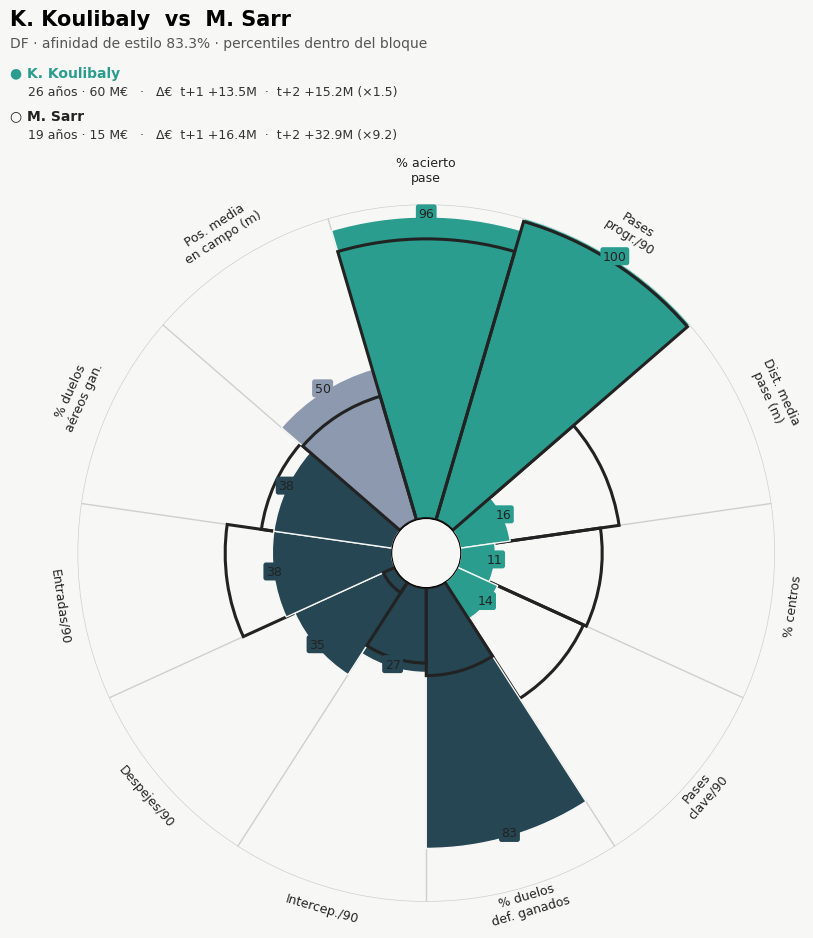

In [32]:
ficha_comparativa("K. Koulibaly", "M. Sarr");   # caso A: central de élite vs relevo joven

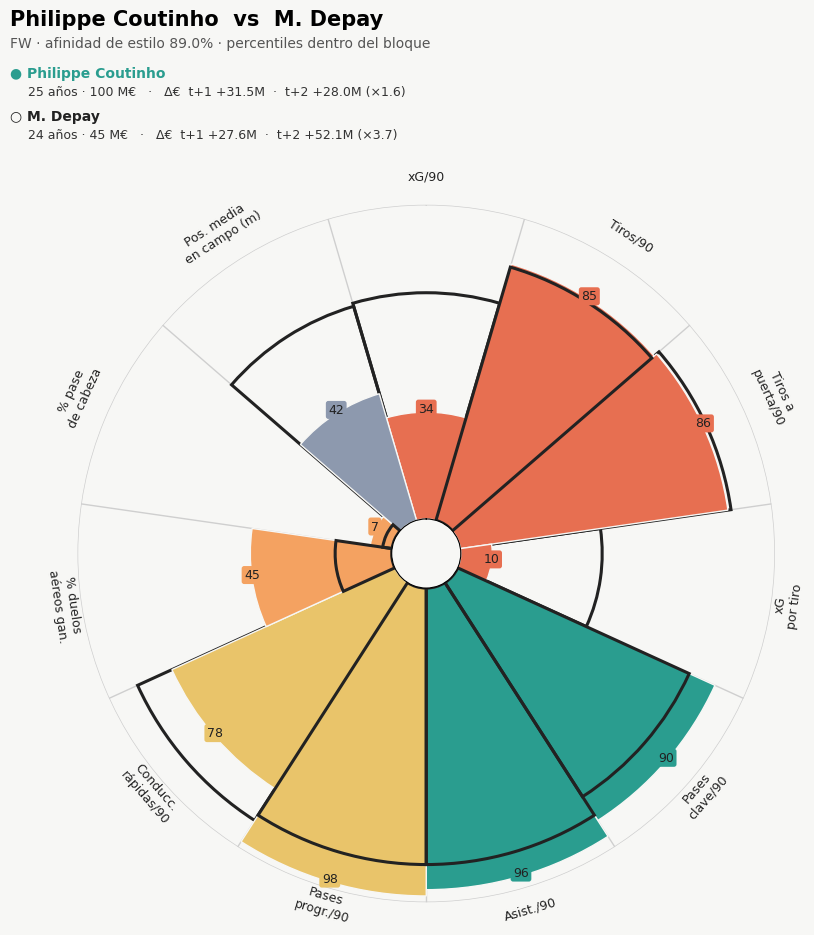

In [33]:
ficha_comparativa("Philippe Coutinho", "M. Depay");   # caso B: creador vs su perfil más afín

Las dos fichas traducen la afinidad numérica a una imagen legible. En la primera,
el central de élite y su relevo joven solapan sus perfiles en las métricas que
definen al central de salida —acierto y volumen de pase, progresión, posición
media adelantada—, la firma visual de una afinidad del 83%. La cabecera completa
la lectura con la dimensión de decisión: el candidato es ocho años más joven,
cuesta cuarenta y cinco millones menos y presenta una revalorización esperada a
dos años muy superior, de modo que la figura no solo dice que se parecen, sino
que el parecido viene acompañado de recorrido económico. La segunda ficha, sobre
el bloque de mayor afinidad de todo el análisis, muestra dos creadores casi
calcados en tiro, asistencia, pases clave y conducción —un 89% que se ve gajo a
gajo—, donde de nuevo el candidato es más joven, más asequible y de mayor
proyección a medio plazo.

La ficha cierra el sistema por el lado del usuario: combina el qué juega
—percentiles de estilo dentro del bloque—, el cuánto cuesta —edad y valor— y el
cuánto puede revalorizarse —las dos estimaciones del predictor—, sin perder el
anclaje en el estilo que vertebra el proyecto. Es la pieza que convierte una
métrica de afinidad en una herramienta de decisión que un cuerpo técnico puede
leer en segundos.

## 6. Dataset abierto y limitaciones

El notebook cierra publicando el conjunto de datos sobre el que se ha trabajado,
de modo que cualquier tercero pueda reproducir los resultados o construir sobre
ellos. El dataset publicado es deliberadamente más amplio que el de
entrenamiento: incluye los 2.295 jugadores con las tres anclas de valoración
—no solo los 2.285 efectivamente entrenados—, pues un recurso abierto debe ser
completo, mientras que el conjunto de entrenamiento excluyó diez casos con valor
de origen desactualizado para no contaminar el aprendizaje. Una columna marca
esa distinción, y las predicciones del modelo se publican únicamente para los
jugadores que recibieron una estimación honesta fuera de muestra; los diez
excluidos conservan sus datos pero no una predicción, que en su caso carecería
de validez.

In [29]:
# Recuperar de gold las features completas de los 10 excluidos (están en gold, no en df)
excl_tm_list = [t for t in V.index if t not in set(df["tm_id"])]
bridge_excl = pd.read_sql(
    "SELECT player_id, tm_id FROM gold.player_market_values WHERE tm_id IS NOT NULL", engine)
bridge_excl = bridge_excl[bridge_excl["tm_id"].isin(excl_tm_list)]

sps_excl = pd.read_sql("SELECT * FROM gold.player_stats_per90", engine) \
             .merge(bridge_excl, on="player_id")            # features + tm_id de los 10

# Targets de los 10 desde V (anclas), por tm_id
tgt_excl = V.loc[excl_tm_list].copy()
for h, (a, b) in {"t1": ("t1", "t0"), "t2": ("t2", "t0")}.items():
    tgt_excl[f"delta_{h}"] = tgt_excl[a] - tgt_excl[b]
    tgt_excl[f"mult_{h}"] = tgt_excl[a] / tgt_excl[b]
tgt_excl = tgt_excl.reset_index().rename(columns={"player_id": "tm_id"})

excluidos = sps_excl.merge(tgt_excl, on="tm_id")             # 10 filas completas: features + anclas + targets

# Dataset publicado: entrenados (con predicción) + excluidos (sin predicción), mismo esquema
entrenados = df.merge(scout[["tm_id", "pred_delta_t1", "pred_delta_t2"]], on="tm_id", how="left")
entrenados["en_entrenamiento"] = True
excluidos["en_entrenamiento"] = False

publicado = pd.concat([entrenados, excluidos], ignore_index=True)

print("Dataset publicado:", publicado.shape)
print("  entrenados:", int(publicado["en_entrenamiento"].sum()),
      "· excluidos:", int((~publicado["en_entrenamiento"]).sum()))
print("  filas con todas las features (sin NaN en una feature de muestra):",
      int(publicado["touches_per90"].notna().sum()))
print("  con predicción:", int(publicado["pred_delta_t1"].notna().sum()))

Dataset publicado: (2295, 78)
  entrenados: 2285 · excluidos: 10
  filas con todas las features (sin NaN en una feature de muestra): 2295
  con predicción: 2285


In [30]:
# Orden legible: identificadores y contexto primero, salida del modelo al final
id_cols   = ["player_id", "tm_id", "short_name", "position_group", "age_at_season"]
ancla_cols = ["t0", "t1", "t2"]
target_cols = ["delta_t1", "delta_t2", "mult_t1", "mult_t2"]
pred_cols  = ["pred_delta_t1", "pred_delta_t2", "en_entrenamiento"]
feat_cols  = [c for c in publicado.columns
              if c not in id_cols + ancla_cols + target_cols + pred_cols]

publicado_out = publicado[id_cols + feat_cols + ancla_cols + target_cols + pred_cols]

OUT = Path.cwd().parents[0] / "data" / "processed"
OUT.mkdir(parents=True, exist_ok=True)
ruta = OUT / "scouting_dataset.csv"
publicado_out.to_csv(ruta, index=False)

print(f"Guardado: {ruta.relative_to(Path.cwd().parents[0])}")
print(f"  {publicado_out.shape[0]} jugadores × {publicado_out.shape[1]} columnas")
print(f"  {publicado_out['en_entrenamiento'].sum()} entrenados · "
      f"{(~publicado_out['en_entrenamiento']).sum()} excluidos (datos completos, sin predicción)")

Guardado: data/processed/scouting_dataset.csv
  2295 jugadores × 78 columnas
  2285 entrenados · 10 excluidos (datos completos, sin predicción)


El dataset se publica en formato CSV, accesible sin herramientas
especializadas y visualizable directamente en el repositorio. Reúne, para cada
uno de los 2.295 jugadores, sus identificadores, el bloque posicional, las
cincuenta y nueve variables de estilo y producción de la temporada 2017/18, los
valores de mercado en las tres fechas ancla, los targets de revalorización
derivados de ellos y, para los efectivamente entrenados, la predicción del modelo
en ambos horizontes. La columna en_entrenamiento permite reproducir con exactitud
la partición empleada, separando los diez casos excluidos por valor de origen
desactualizado. Es, por tanto, un recurso autocontenido y auditable: cualquier
tercero puede verificar tanto sobre qué se entrenó el modelo como qué predijo.

### Limitaciones del modelo de rentabilidad

El predictor de revalorización debe interpretarse a la luz de varias limitaciones,
todas asumidas de forma explícita. La primera y más estructural es que las
características de entrada proceden de una única temporada: el modelo aprende de
una sola fotografía del juego de cada futbolista, no de su trayectoria. No es,
por tanto, un modelo de series temporales sino una estimación transversal —dado
cómo jugó un futbolista en 2017/18 y su valor entonces, cuánto se revalorizará—,
y no captura dinámicas como la progresión sostenida o el declive paulatino que
solo varias temporadas revelarían.

La segunda afecta al bloque de porteros, cuyo predictor se ha mostrado poco
fiable en ambos horizontes. La causa no es metodológica sino de fondo: el valor
de mercado de un guardameta depende en gran medida de factores que los datos de
evento de una temporada no recogen, y la muestra del bloque es además la más
reducida. Sus predicciones se publican por completitud, pero deben tomarse con
cautela; la utilidad de los porteros en el sistema reside en el motor de
similitud de estilo, no en la estimación económica.

La tercera es la dependencia del valor de mercado de Transfermarkt como variable
objetivo. Es una estimación colaborativa, no un precio de transacción, y como
tal incorpora el juicio agregado de una comunidad —con sus sesgos hacia las ligas
y los clubes más visibles— más que un valor de mercado puro. El modelo aprende a
predecir esa estimación, con sus virtudes y sus sesgos. A ello se añade que la
frescura de las valoraciones de destino no se verificó por fecha como sí se hizo
con la de origen, de modo que una fracción de los targets podría reflejar
valoraciones no plenamente actualizadas.

La cuarta delimita el alcance de las predicciones: el modelo se ha validado y
aplicado dentro de la cohorte de jugadores de las cinco grandes ligas en 2017/18.
Sus estimaciones son honestas para ordenar a esos futbolistas entre sí —el
propósito de un priorizador de scouting—, pero extrapolarlas a fichajes de otras
competiciones o temporadas exigiría reentrenar el modelo sobre datos
representativos de ese nuevo contexto.

Estas limitaciones no invalidan el sistema, sino que precisan su lugar. El modelo
no tasa el precio exacto de un jugador ni emite veredictos de fichaje: ordena un
espacio de candidatos por revalorización esperada, con razones futbolísticas
interpretables, y deja la decisión final al criterio humano. Es, en esa función
acotada y declarada, una herramienta de scouting útil y honesta.